In [2]:
import pandas as pd
import lightgbm as lgb
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import requests
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
import stumpy
import numpy as np
from scipy.spatial.distance import cdist
import os
import random
import matplotlib.cm as cm

from distancematrix import AnytimeCalculator
from distancematrix.consumer import MatrixProfileLR
from distancematrix.generator import ZNormEuclidean
from distancematrix.generator import Euclidean
from distancematrix.insights import highest_value_idxs, lowest_value_idxs

from scipy.spatial.distance import cdist
from numpy.lib.stride_tricks import sliding_window_view

from scipy.sparse import lil_matrix, csr_matrix
import matplotlib.ticker as mticker

In [3]:
VIRTUOSO_URL = "http://localhost:8890/sparql"
GRAPH_URI    = "http://example.com/Gent-Terneuzen"
USERNAME     = "dba"
PASSWORD     = "dba"
AUTH         = (USERNAME, PASSWORD)

In [4]:
params  = {'graph': GRAPH_URI}
headers = {'Accept': 'text/turtle'}

# Identifying unique sensors


In [5]:
sensor_set = set()

sensor_query = f"""
    PREFIX sosa: <http://www.w3.org/ns/sosa/>
    SELECT DISTINCT ?sensor
    WHERE {{
        GRAPH <{GRAPH_URI}> {{
            ?obs a sosa:Observation ;
                 sosa:madeBySensor ?sensor .
        }}
    }}
    """
res = requests.get(VIRTUOSO_URL, params={'query': sensor_query, 'format': 'application/sparql-results+json'})
if res.status_code != 200:
    print(f"Error: {res.status_code}")
    print("Response:", res.text)
else:
    print("Unique sensors identified successfully!")

data     = res.json()
bindings = data['results']['bindings']
for row in bindings:
    sensor_set.add(row['sensor']['value'])

print(f"Added {len(sensor_set)} unique sensors to the set.")
print("Sensors:", sensor_set)

Unique sensors identified successfully!
Added 4 unique sensors to the set.
Sensors: {'http://example.com/waterinfo/289441042', 'http://example.com/waterinfo/289429042', 'http://example.com/waterinfo/289435042', 'http://example.com/waterinfo/289423042'}


# Reframe the data

In [6]:
final_df = pd.DataFrame()
print("Fetching and pivoting sensor data...")

for sensor_uri in sensor_set:
    column_name = sensor_uri.split('/')[-1]
    query = f"""
        PREFIX sosa: <http://www.w3.org/ns/sosa/>
        PREFIX ex: <http://example.com/attributes/>
        SELECT ?time ?value ?unixtime
        WHERE {{
            GRAPH <{GRAPH_URI}> {{
                ?obs a sosa:Observation ;
                    sosa:resultTime ?time ;
                    sosa:hasSimpleResult ?value ;
                    ex:unixTimestamp ?unixtime ;
                    sosa:madeBySensor <{sensor_uri}> .
            }}
        }}
    """
    res = requests.get(VIRTUOSO_URL, params={'query': query, 'format': 'application/sparql-results+json'})
    if res.status_code == 200:
        bindings = res.json()['results']['bindings']
        temp_data = [
            {'time': row['time']['value'], column_name: float(row['value']['value']),
             'unixtime': int(row['unixtime']['value'])}
            for row in bindings
        ]
        temp_df = pd.DataFrame(temp_data)
        if not temp_df.empty:
            temp_df['time'] = pd.to_datetime(temp_df['time'])
            if final_df.empty:
                final_df = temp_df
            else:
                final_df = pd.merge(final_df, temp_df, on=['time', 'unixtime'], how='outer')
            print(f"Added column for sensor: {column_name}")

final_df = final_df.sort_values('time').set_index('time')
print("Finished!")
print(final_df.head())

Fetching and pivoting sensor data...
Added column for sensor: 289441042
Added column for sensor: 289429042
Added column for sensor: 289435042
Added column for sensor: 289423042
Finished!
                           289441042    unixtime  289429042  289435042  \
time                                                                     
2021-03-03 23:15:00+00:00    4797.72  1614813300    1605.77    3606.54   
2021-03-03 23:30:00+00:00    4717.80  1614814200        NaN        NaN   
2021-03-03 23:45:00+00:00    4745.36  1614815100    1602.34    3556.45   
2021-03-04 00:00:00+00:00        NaN  1614816000    1611.26        NaN   
2021-03-04 00:15:00+00:00        NaN  1614816900    1614.24        NaN   

                           289423042  
time                                  
2021-03-03 23:15:00+00:00        NaN  
2021-03-03 23:30:00+00:00        NaN  
2021-03-03 23:45:00+00:00     902.27  
2021-03-04 00:00:00+00:00        NaN  
2021-03-04 00:15:00+00:00     901.96  


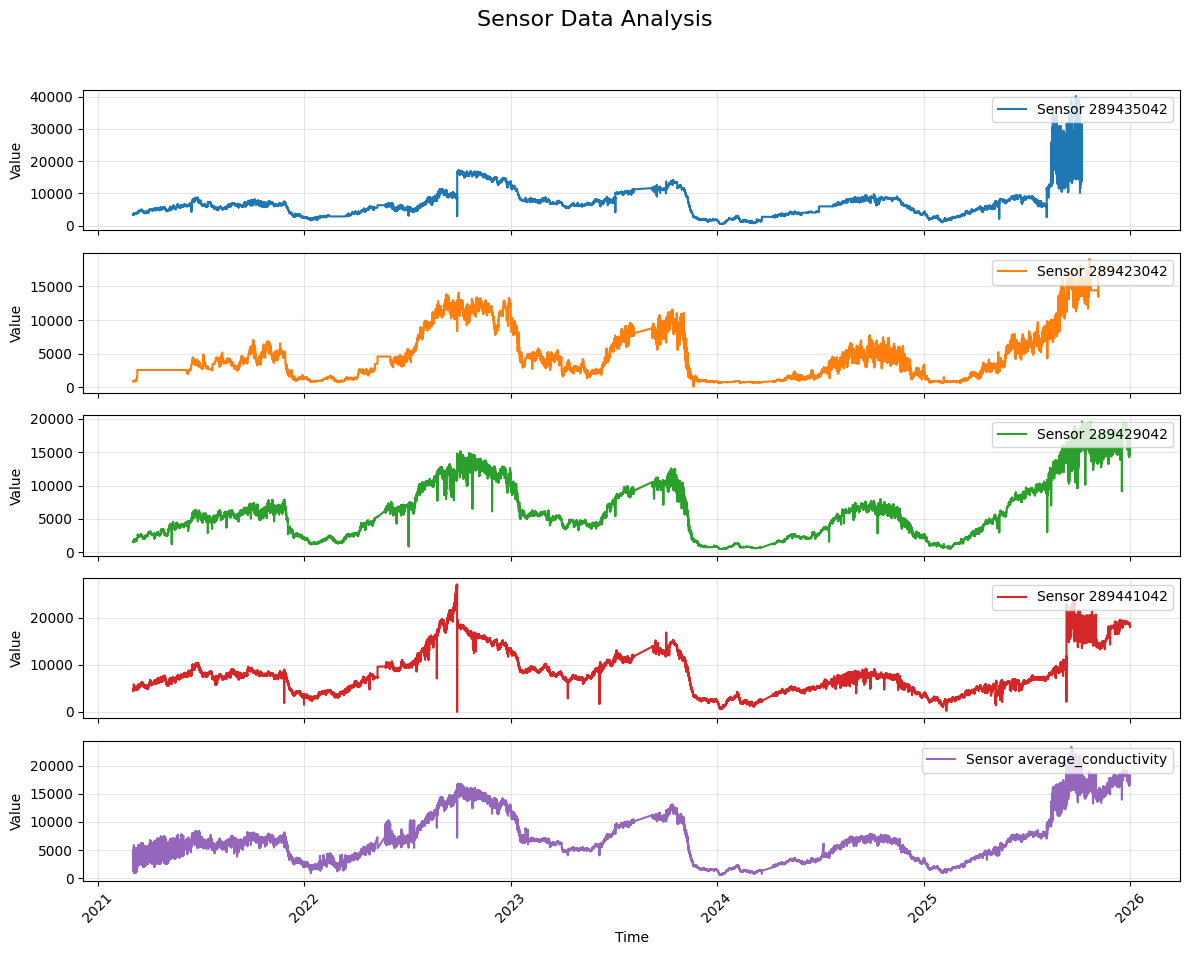

In [7]:
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 10), sharex=True)

sensors = ['289435042', '289423042', '289429042', '289441042']
colors  = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728','#9467bd']
final_df['average_conductivity'] = final_df[sensors].mean(axis=1)
final_df = final_df.bfill()
sensors_with_avg = sensors + ['average_conductivity']

for i, sensor in enumerate(sensors_with_avg):
    ax = axes[i]
    ax.plot(final_df.index, final_df[sensor], label=f"Sensor {sensor}", color=colors[i])
    ax.set_ylabel("Value")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle("Sensor Data Analysis", fontsize=16)
plt.xlabel("Time")
plt.xticks(rotation=45)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Matrix profile

In [11]:
# STUMPY doesn't handle NaNs, so we interpolate missing values
signal = final_df['average_conductivity'].interpolate(method='linear').bfill().ffill().values
# 96 periods * 15 mins = 24 hours. 8640 = 3 months (season). 2880 = 1 month
m = 96*7
# Compute the matrix profile
mp = stumpy.stump(signal, m)
#Find the Motif (most repeated pattern) and Discord (biggest anomaly)
# 1. Choose how many you want to find
top_n = 5
# Exclusion zone: once we find a motif/discord, skip 'm' points so we don't pick the same event twice
exclusion_zone = m 

# --- MULTIPLE DISCORDS (Top Peaks) ---
# We sort indices by distance in descending order (highest first)
sorted_indices = np.argsort(mp[:, 0])[::-1]
discords = []
for idx in sorted_indices:
    if len(discords) >= top_n:
        break
    # Check if this index is far enough away from already found discords
    if all(abs(idx - d) > exclusion_zone for d in discords):
        discords.append(idx)

# --- MULTIPLE MOTIFS (Lowest Valleys) ---
# We sort indices by distance in ascending order (lowest first)
sorted_indices = np.argsort(mp[:, 0])
motifs = []
for idx in sorted_indices:
    if len(motifs) >= top_n:
        break
    if all(abs(idx - m_idx) > exclusion_zone for m_idx in motifs):
        motifs.append(idx)

# Print results
print(f"Top {top_n} Discord indices:", discords)
print(f"Top {top_n} Motif indices:", motifs)

Top 5 Discord indices: [np.int64(1012), np.int64(2990), np.int64(4110), np.int64(17079), np.int64(1685)]
Top 5 Motif indices: [np.int64(88198), np.int64(96444), np.int64(92893), np.int64(69505), np.int64(95654)]


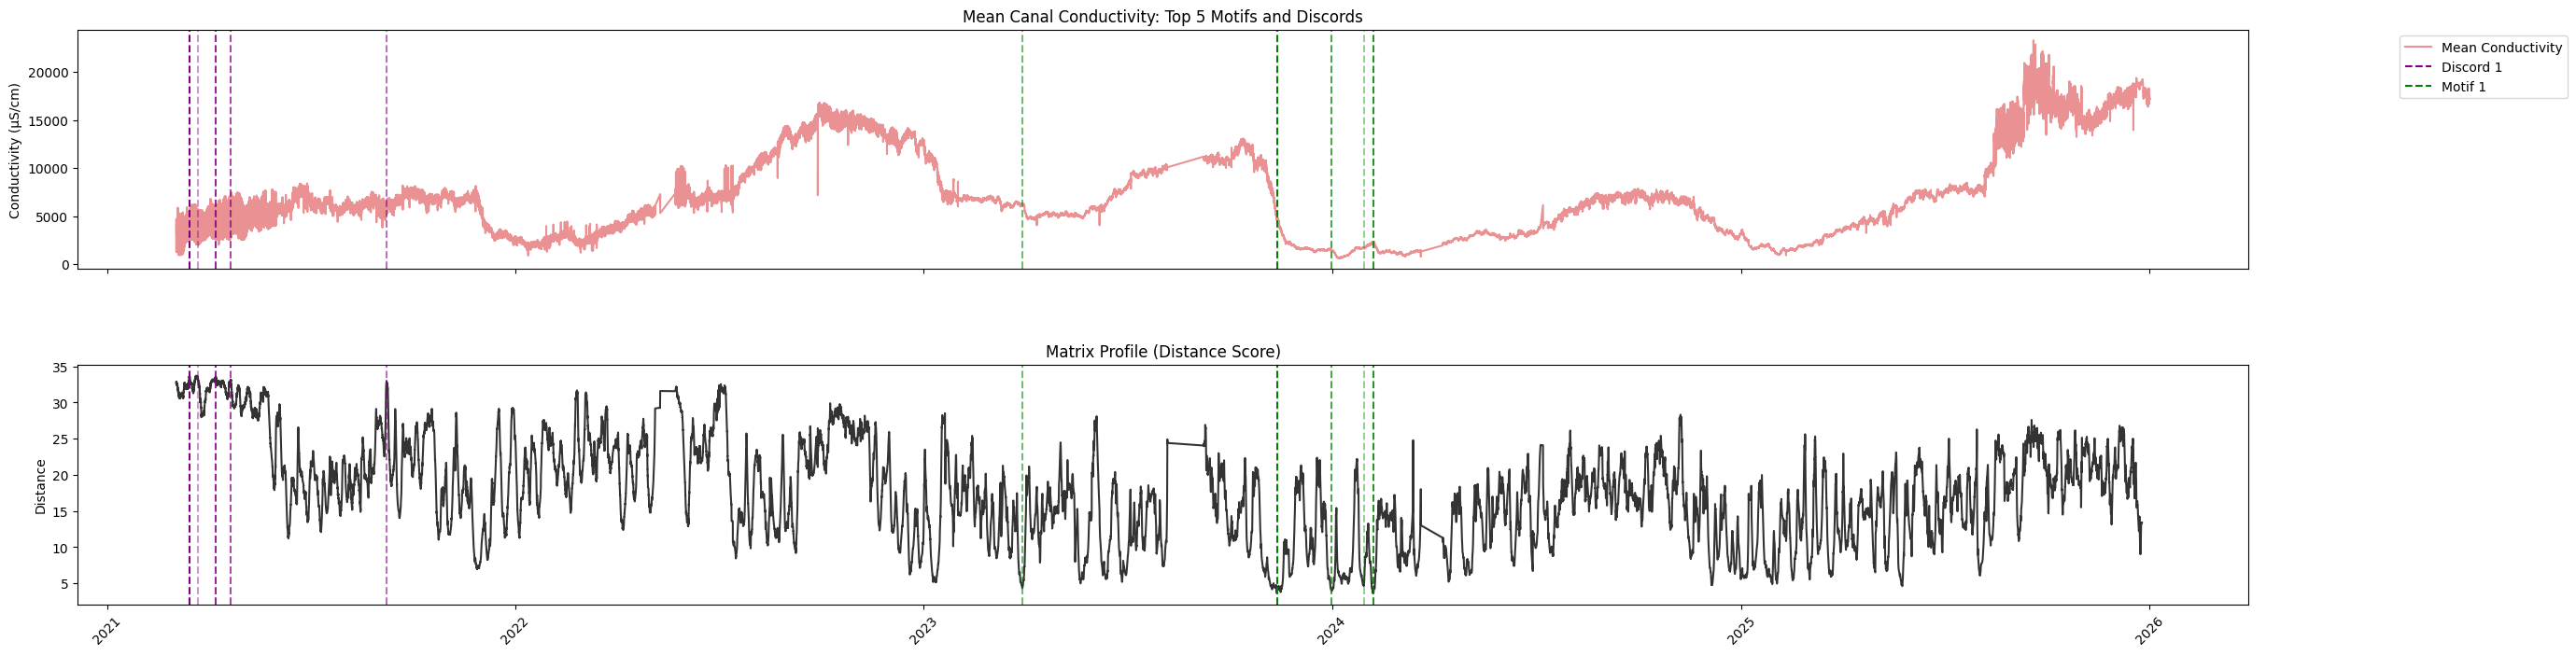

In [8]:
# Choose how many you want to display (matches the lists from the previous step)
n_to_plot = 5 

# Visualization
fig, axs = plt.subplots(2, sharex=True, gridspec_kw={'hspace': 0.4}, figsize=(30, 8))

# 1. TOP PLOT: Raw Signal (Average Conductivity)
axs[0].plot(final_df.index, signal, color='#d62728', alpha=0.5, label='Mean Conductivity')
axs[0].set_title(f'Mean Canal Conductivity: Top {n_to_plot} Motifs and Discords')
axs[0].set_ylabel('Conductivity (μS/cm)')

# 2. BOTTOM PLOT: Matrix Profile
axs[1].plot(final_df.index[:len(mp)], mp[:, 0], color='black', alpha=0.8)
axs[1].set_title('Matrix Profile (Distance Score)')
axs[1].set_ylabel('Distance')

# 3. LOOP TO ADD MULTIPLE LINES
# Using 'Purples' for discords and 'Greens' for motifs
for i in range(len(discords)):
    alpha_val = 1.0 - (i * 0.15) # Make the top discord darker than the others
    axs[0].axvline(x=final_df.index[discords[i]], color='purple', linestyle='--', alpha=alpha_val, label=f'Discord {i+1}' if i==0 else "")
    axs[1].axvline(x=final_df.index[discords[i]], color='purple', linestyle='--', alpha=alpha_val)

for i in range(len(motifs)):
    alpha_val = 1.0 - (i * 0.15)
    axs[0].axvline(x=final_df.index[motifs[i]], color='green', linestyle='--', alpha=alpha_val, label=f'Motif {i+1}' if i==0 else "")
    axs[1].axvline(x=final_df.index[motifs[i]], color='green', linestyle='--', alpha=alpha_val)

axs[0].legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.xticks(rotation=45)
plt.show()

# Multi dimension Matrix Profile

In [12]:
T = np.array([final_df[s].interpolate(method='linear').bfill().ffill().values for s in sensors]) #fill empty values
m = 96 * 7  # 1-week window

CACHE_FILE = "mstump_cache.npz"

if os.path.exists(CACHE_FILE):
    print("Loading cached matrix profile...")
    cache = np.load(CACHE_FILE)
    mmp   = cache["mmp"]
    mmp_I = cache["mmp_I"]
    print("Done.")
else:
    print("Computing mstump")
    mmp, mmp_I = stumpy.mstump(T, m)
    np.savez(CACHE_FILE, mmp=mmp, mmp_I=mmp_I)
    print(f"Saved to {CACHE_FILE}")


aggregate_profile = mmp[-1]  # all-dimensions combined

def find_peaks(profile, top_n, exclusion_zone, ascending=True): #Find Motifs & Discords from the 1D aggregate profile
    found = []
    for idx in np.argsort(profile)[::1 if ascending else -1]:
        if len(found) >= top_n: break
        if all(abs(idx - f) > exclusion_zone for f in found):
            found.append(int(idx))
    return found

#Find Motifs & Discords
motifs   = find_peaks(aggregate_profile, top_n=3, exclusion_zone=m, ascending=True)
discords = find_peaks(aggregate_profile, top_n=3, exclusion_zone=m, ascending=False)


Loading cached matrix profile...
Done.


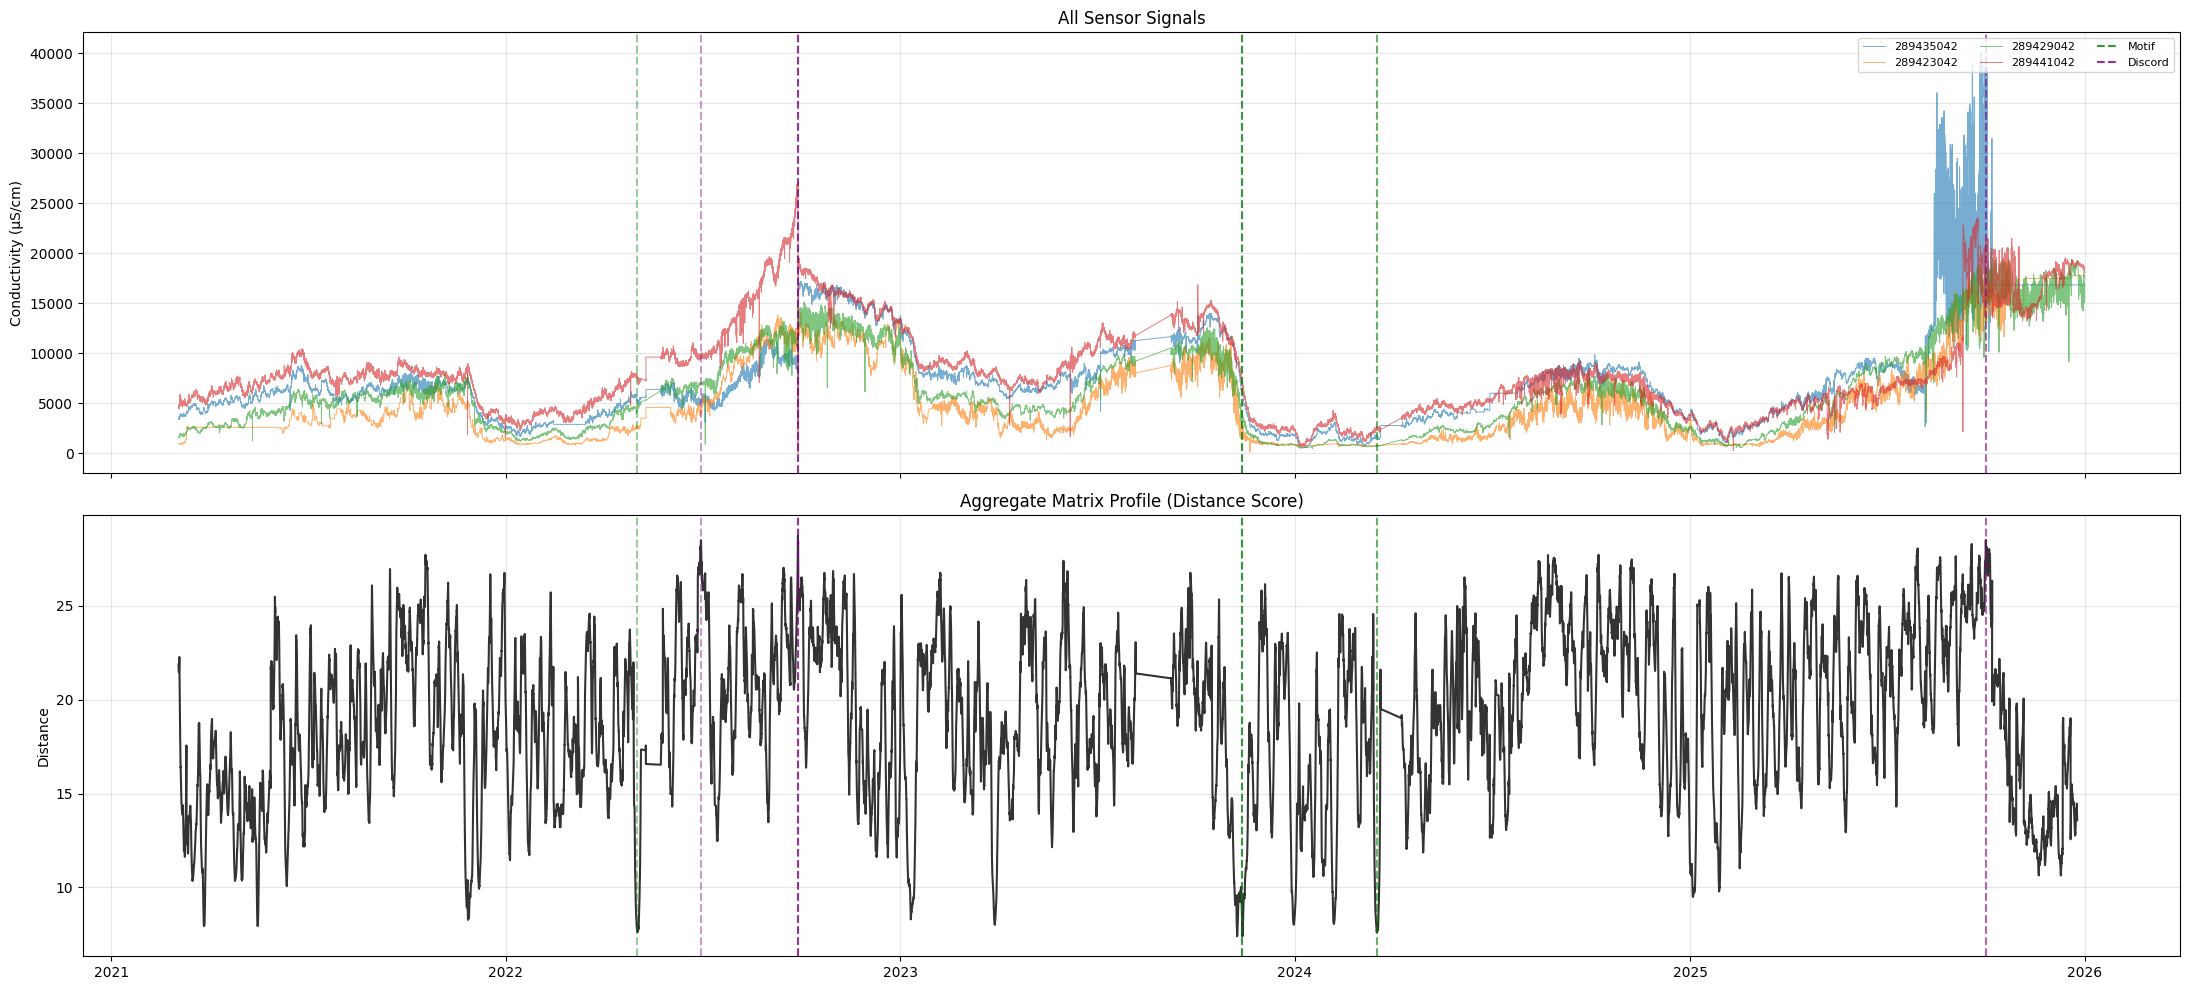

In [13]:
time_index = final_df.index
colors_sensor = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 1, figsize=(22, 10), sharex=True)

# Panel A: All sensor signals
for s, col in zip(sensors, colors_sensor):
    axes[0].plot(time_index, final_df[s].interpolate().values, label=s, color=col, alpha=0.6, linewidth=0.7)
axes[0].set(title='All Sensor Signals', ylabel='Conductivity (μS/cm)')
axes[0].grid(True, alpha=0.3)

# Panel B: Aggregate matrix profile
axes[1].plot(time_index[:len(aggregate_profile)], aggregate_profile, color='black', alpha=0.8)
axes[1].set(title='Aggregate Matrix Profile (Distance Score)', ylabel='Distance')
axes[1].grid(True, alpha=0.3)

# Overlay motifs/discords on both panels
for ax in axes:
    for i, idx in enumerate(motifs):
        ax.axvline(time_index[idx], color='green',  linestyle='--', alpha=0.8 - i*0.2, label='Motif'   if (i == 0 and ax == axes[0]) else None)
    for i, idx in enumerate(discords):
        ax.axvline(time_index[idx], color='purple', linestyle='--', alpha=0.8 - i*0.2, label='Discord' if (i == 0 and ax == axes[0]) else None)

axes[0].legend(loc='upper right', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()

In [14]:
m = 96*7
resampled_df = final_df.resample('D').mean().interpolate()
ts_data = resampled_df['average_conductivity'].values
print("Calculating Contextual Matrix Profile with STUMPY...")

# 3. Create Sliding Windows
subsequences = sliding_window_view(ts_data, window_shape=m)

# 4. Calculate Distance Matrix (Now much smaller!)
print(f"Calculating matrix for {len(subsequences)} windows...")
dist_matrix = cdist(subsequences, subsequences, metric='euclidean')

# 5. Create the Diagonal Split
upper_tri = np.triu(dist_matrix)
# The image shows a darker/different contrast on the bottom
lower_tri = np.tril(dist_matrix * 0.4) 
combined_matrix = upper_tri + lower_tri

Calculating Contextual Matrix Profile with STUMPY...
Calculating matrix for 1094 windows...


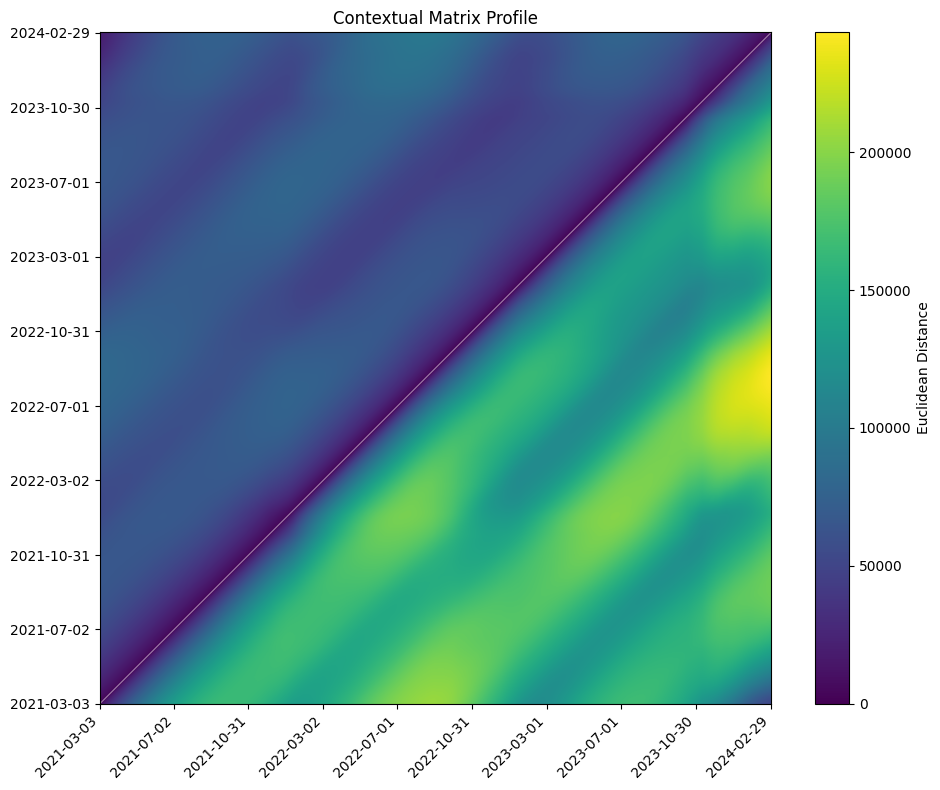

In [17]:
# 6. Plotting
fig, ax = plt.subplots(figsize=(10, 8))
n_windows = len(subsequences)

# Use 'magma' or 'viridis' for that CMP look
im = ax.imshow(combined_matrix, aspect='equal', cmap='viridis', origin='lower',
               extent=[0, n_windows, 0, n_windows])

# Add the white diagonal divider
ax.plot([0, n_windows], [0, n_windows], color='white', linewidth=0.8, alpha=0.5)

# Formatting Labels
num_ticks = 10
tick_indices = np.linspace(0, n_windows - 1, num_ticks, dtype=int)
xtick_labels = resampled_df.index[tick_indices].strftime('%Y-%m-%d')
ytick_labels = resampled_df.index[tick_indices].strftime('%Y-%m-%d')

ax.set_xticks(tick_indices)
ax.set_xticklabels(xtick_labels, rotation=45, ha='right')
ax.set_yticks(tick_indices)
ax.set_yticklabels(ytick_labels)

plt.colorbar(im, label='Euclidean Distance')
plt.title(f"Contextual Matrix Profile")
plt.tight_layout()
plt.show()